# Phase 3: Full QUICHE recovery test

### Initilize

In [1]:
import os
os.environ["R_HOME"] = "/work/nagar_F2657_csv/miniconda3/envs/venv_quiche_3D_simple/lib/R"

import sim_unstructured as sim
from collections import Counter

import os
import pandas as pd
import numpy as np
import quiche as qu
import scanpy as sc
import anndata as ad
import squidpy as sq
import matplotlib.pyplot as plt

%reload_ext autoreload
%load_ext autoreload
%autoreload 2
%matplotlib inline

#sc.set_figure_params(dpi = 400, dpi_save = 400, fontsize = 14)
#sc.set_figure_params(dpi = 120, dpi_save = 300, fontsize = 14) # smaller plots for now

/work/nagar_F2657_csv/miniconda3/envs/venv_quiche_3D_simple/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/work/nagar_F2657_csv/miniconda3/envs/venv_quiche_3D_simple/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


To use sccoda or tasccoda please install ete3 with pip install ete3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generate baseline simulation and covert to AnnData

In [2]:
cfg = sim.SimConfig(
    n_patients=20,
    n_conditions=2,
    cells_per_patient=5000,
    domain_size=300.0,
    grid_size=3,
    prevalence=1.0,
    random_state=42,
    preserve_global_counts=True,
)

cells, meta = sim.simulate_cohort(cfg)

print(meta.head())

  patient_id  condition  has_niche  grid_size  domain_size  voxel_ix  \
0        P00          0       True          3        300.0         1   
1        P01          0       True          3        300.0         1   
2        P02          0       True          3        300.0         0   
3        P03          0       True          3        300.0         2   
4        P04          0       True          3        300.0         1   

   voxel_iy  voxel_iz  theoretical_region_fraction  n_cells_in_voxel  \
0         0         1                     0.037037               179   
1         2         0                     0.037037               177   
2         2         2                     0.037037               195   
3         2         1                     0.037037               196   
4         1         0                     0.037037               184   

   realized_region_fraction gt_niche_type  \
0                    0.0358    ACE_region   
1                    0.0354    ACE_region   

In [3]:
cells = cells.copy()

cells["condition"] = cells["condition"].astype(str)
cells["fov"] = cells["patient_id"]
cells["cell_cluster"] = pd.Categorical(cells["cell_type"])
cells["label"] = cells["cell_id"].astype(str)

X_df = pd.get_dummies(cells["cell_cluster"], dtype=float)
X = X_df.to_numpy()

adata = ad.AnnData(X=X)
adata.obs_names = cells["cell_id"].astype(str).values

adata.obs = cells[
    [
        "patient_id",
        "condition",
        "fov",
        "label",
        "cell_cluster",
        "cell_type",
        "gt_region_label",
        "in_niche_voxel",
    ]
].copy()
adata.obs.index = adata.obs_names
adata.obs = adata.obs.rename(columns={"patient_id": "Patient_ID"})

adata.obs["Patient_ID"] = adata.obs["Patient_ID"].astype("category")
adata.obs["fov"] = adata.obs["fov"].astype("category")
adata.obs["condition"] = adata.obs["condition"].astype("category")
adata.obs["cell_cluster"] = pd.Categorical(adata.obs["cell_cluster"])

adata.obsm["spatial3d"] = cells[["x", "y", "z"]].to_numpy().astype(float)

adata.var_names = X_df.columns.astype(str)

adata

AnnData object with n_obs × n_vars = 100000 × 5
    obs: 'Patient_ID', 'condition', 'fov', 'label', 'cell_cluster', 'cell_type', 'gt_region_label', 'in_niche_voxel'
    obsm: 'spatial3d'

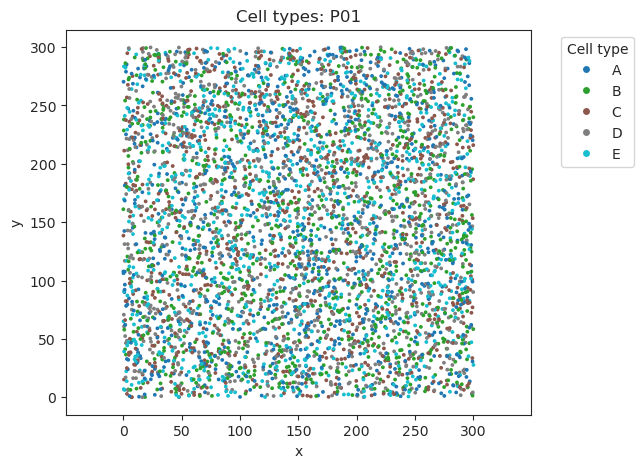

In [19]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sample_id = adata.obs["Patient_ID"].cat.categories[1]

adata_s = adata[adata.obs["Patient_ID"] == sample_id].copy()
coords = adata_s.obsm["spatial3d"]

labels = adata_s.obs["cell_cluster"]
codes = labels.cat.codes
categories = labels.cat.categories

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    coords[:, 0],
    coords[:, 1],
    s=3,
    c=codes,
    cmap="tab10",
)

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=cat,
        markerfacecolor=scatter.cmap(scatter.norm(i)),
        markersize=6,
    )
    for i, cat in enumerate(categories)
]

plt.legend(
    handles=legend_handles,
    title="Cell type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.title(f"Cell types: {sample_id}")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

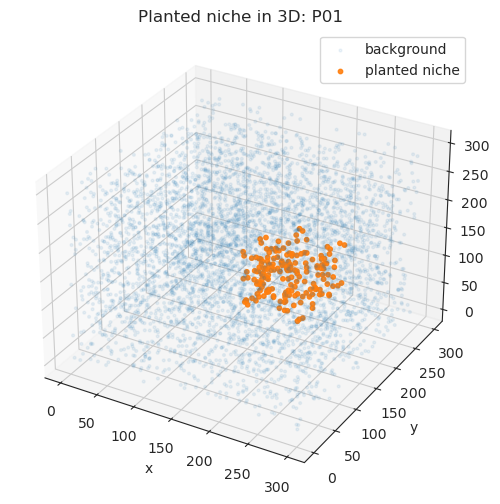

In [20]:
sample_id = adata.obs["Patient_ID"].cat.categories[1]

adata_s = adata[adata.obs["Patient_ID"] == sample_id].copy()
coords = adata_s.obsm["spatial3d"]

# choose the truth column from your simulator
niche_mask = adata_s.obs["gt_region_label"].isin(["ACE_region", "BD_region"]).to_numpy()

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

# background cells: transparent grey
ax.scatter(
    coords[~niche_mask, 0],
    coords[~niche_mask, 1],
    coords[~niche_mask, 2],
    s=4,
    alpha=0.08,
    label="background",
)

# niche cells: opaque
ax.scatter(
    coords[niche_mask, 0],
    coords[niche_mask, 1],
    coords[niche_mask, 2],
    s=10,
    alpha=0.9,
    label="planted niche",
)

ax.set_title(f"Planted niche in 3D: {sample_id}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()

plt.show()

## Initialize QUICHE

In [5]:
quiche_op = qu.tl.QUICHE(
    adata=adata,
    labels_key="cell_cluster",
    spatial_key="spatial3d",
    fov_key="fov",
    patient_key="Patient_ID",
    segmentation_label_key="label",
)

INFO:quiche.tools.quiche:Converted 'fov' to categorical.


In [6]:
quiche_op.compute_spatial_niches(
    radius=25,
    n_neighbors=30,
    khop=None,
    min_cell_threshold=3,
    coord_type="generic",
    delaunay=False,
)

INFO:quiche.tools.quiche:Computing spatial niches...


Skipping subsampling for now, in order to keep max signal intact

In [7]:
quiche_op.subsample(sketch_size=None)

INFO:quiche.tools.quiche:Skipping distribution-focused downsampling.


### Run Differential Enrichment

In [8]:
quiche_op.differential_enrichment(
    k_sim=50,                      # smaller = better for rare/local niches
    design="~condition",
    model_contrasts="condition1-condition0",
)

INFO:quiche.tools.quiche:Testing for differential spatial enrichment across conditions...


### Inspect Results

In [9]:
quiche_var = quiche_op.mdata["quiche"].var.copy()

display(quiche_var.head())

# sort by significance
display(
    quiche_var.sort_values("SpatialFDR").head(20)
)

,index_cell,kth_distance,logFC,logCPM,F,PValue,FDR,SpatialFDR,-log10(SpatialFDR),-log10(PValue),...,condition,fov,label,cell_cluster,cell_type,gt_region_label,in_niche_voxel,nhood_ixs_random,nhood_ixs_refined,nhood_kth_distance
0,0,0.056371,0.152450,3.925103,0.090895,0.763042,0.961358,0.963114,1.632242e-02,0.117452,...,0,P00,P00_cell_0,B,B,background,False,1,1,0.056371
1,1,0.117851,0.003910,3.484884,0.000030,0.995610,0.999999,0.999999,5.376716e-07,0.001911,...,0,P00,P00_cell_1,D,D,background,False,1,1,0.117851
2,2,0.060606,-0.530218,3.700012,0.794136,0.372853,0.853340,0.854301,6.838915e-02,0.428463,...,0,P00,P00_cell_2,B,B,background,False,1,1,0.060606
3,3,0.064788,0.104547,4.231930,0.065175,0.798496,0.965964,0.966801,1.466299e-02,0.097727,...,0,P00,P00_cell_3,A,A,background,False,1,1,0.064788
4,4,0.091054,-0.547811,3.999647,1.286869,0.256626,0.780266,0.779221,1.083395e-01,0.590700,...,0,P00,P00_cell_4,C,C,background,False,1,1,0.091054


,index_cell,kth_distance,logFC,logCPM,F,PValue,FDR,SpatialFDR,-log10(SpatialFDR),-log10(PValue),...,condition,fov,label,cell_cluster,cell_type,gt_region_label,in_niche_voxel,nhood_ixs_random,nhood_ixs_refined,nhood_kth_distance
98744,98773,0.014285,6.159980,4.678361,109.537565,1.239540e-25,2.009975e-21,4.143447e-22,21.382638,24.906739,...,1,P19,P19_cell_3773,D,D,BD_region,True,1,1,0.014285
79163,79185,0.014285,6.160021,4.678387,109.540307,1.237827e-25,2.009975e-21,4.143447e-22,21.382638,24.907340,...,1,P15,P15_cell_4185,D,D,BD_region,True,1,1,0.014285
62927,62946,0.014285,6.159997,4.678372,109.538755,1.238797e-25,2.009975e-21,4.143447e-22,21.382638,24.907000,...,1,P12,P12_cell_2946,B,B,BD_region,True,1,1,0.014285
59931,59949,0.014285,6.160032,4.678394,109.541039,1.237370e-25,2.009975e-21,4.143447e-22,21.382638,24.907501,...,1,P11,P11_cell_4949,B,B,BD_region,True,1,1,0.014285
87271,87294,0.014285,6.159867,4.678290,109.530034,1.244258e-25,2.009975e-21,4.143447e-22,21.382638,24.905089,...,1,P17,P17_cell_2294,D,D,BD_region,True,1,1,0.014285
67555,67575,0.014285,6.159984,4.678364,109.537867,1.239352e-25,2.009975e-21,4.143447e-22,21.382638,24.906805,...,1,P13,P13_cell_2575,B,B,BD_region,True,1,1,0.014285
64057,64076,0.014285,6.143632,4.666977,108.117759,2.537064e-25,3.087086e-21,6.363849e-22,21.196280,24.595669,...,1,P12,P12_cell_4076,D,D,BD_region,True,1,1,0.014285
87042,87065,0.014285,6.143499,4.666894,108.109197,2.548047e-25,3.087086e-21,6.363849e-22,21.196280,24.593793,...,1,P17,P17_cell_2065,D,D,BD_region,True,1,1,0.014285
63654,63673,0.016071,6.057841,4.608031,101.015196,9.141667e-24,5.910657e-20,1.285082e-20,19.891069,23.038975,...,1,P12,P12_cell_3673,B,B,BD_region,True,1,1,0.016071
59005,59023,0.016071,6.057879,4.608053,101.017563,9.130751e-24,5.910657e-20,1.285082e-20,19.891069,23.039494,...,1,P11,P11_cell_4023,C,C,background,False,1,1,0.016071


Each row is a niche neighborhood NOT one cell.

In [21]:
sig = quiche_var[quiche_var["SpatialFDR"] < 0.05].copy()

display(
    sig.groupby("gt_region_label")["logFC"]
    .agg(["count", "mean", "median", "min", "max"])
)

,count,mean,median,min,max
gt_region_label,,,,,
ACE_region,358,-2.024508,-1.918469,-3.443455,1.415837
BD_region,959,3.727256,4.050769,-2.083264,6.160032
background,988,-0.255735,-1.191970,-5.414662,6.057879


ACE_region: Mostly negative logFC -> Enriched in condition 0

BD_region: Mostly positive -> Enriched in condition 1
BD signal strength is stronger than the ACE region, likely because of the number of cells necessary

Background:
Not quite zero, but the mean is close. Some of the background niches might be near the planted region or a mixture.

Counts: Weird assymetry 

In [ ]:
(quiche_var["SpatialFDR"] < 0.05).mean() # proportion of significant niches

0.02305668643906733

In [26]:
display(
    quiche_var.sort_values("logFC", ascending=False)[
        ["logFC", "SpatialFDR", "gt_region_label"]
    ].head(10)
)

,logFC,SpatialFDR,gt_region_label
59931,6.160032,4.143447e-22,BD_region
79163,6.160021,4.143447e-22,BD_region
62927,6.159997,4.143447e-22,BD_region
67555,6.159984,4.143447e-22,BD_region
98744,6.159980,4.143447e-22,BD_region
87271,6.159867,4.143447e-22,BD_region
64057,6.143632,6.363849e-22,BD_region
87042,6.143499,6.363849e-22,BD_region
59005,6.057879,1.285082e-20,background
58869,6.057879,1.285082e-20,background


In [27]:
display(
    quiche_var.sort_values("logFC", ascending=True)[
        ["logFC", "SpatialFDR", "gt_region_label"]
    ].head(10)
)

,logFC,SpatialFDR,gt_region_label
25206,-5.414662,7.167572e-13,background
5443,-5.361193,6.379731e-12,background
14488,-5.360550,4.560293e-12,background
7012,-5.360340,2.816525e-12,background
2884,-5.359702,2.849192e-12,background
3915,-5.359485,2.860346e-12,background
8525,-5.358796,2.896223e-12,background
10156,-5.358611,3.840502e-01,background
22455,-5.358362,2.920874e-12,background
13977,-5.358008,2.937728e-12,background


In [28]:
sig = quiche_var[quiche_var["SpatialFDR"] < 0.05]

print("Top BD-like niches:")
display(
    sig.sort_values("logFC", ascending=False)[
        ["logFC", "SpatialFDR", "gt_region_label"]
    ].head(10)
)

print("\nTop ACE-like niches:")
display(
    sig.sort_values("logFC", ascending=True)[
        ["logFC", "SpatialFDR", "gt_region_label"]
    ].head(10)
)

Top BD-like niches:


,logFC,SpatialFDR,gt_region_label
59931,6.160032,4.143447e-22,BD_region
79163,6.160021,4.143447e-22,BD_region
62927,6.159997,4.143447e-22,BD_region
67555,6.159984,4.143447e-22,BD_region
98744,6.159980,4.143447e-22,BD_region
87271,6.159867,4.143447e-22,BD_region
64057,6.143632,6.363849e-22,BD_region
87042,6.143499,6.363849e-22,BD_region
59005,6.057879,1.285082e-20,background
58869,6.057879,1.285082e-20,background



Top ACE-like niches:


,logFC,SpatialFDR,gt_region_label
25206,-5.414662,7.167572e-13,background
5443,-5.361193,6.379731e-12,background
14488,-5.360550,4.560293e-12,background
7012,-5.360340,2.816525e-12,background
2884,-5.359702,2.849192e-12,background
3915,-5.359485,2.860346e-12,background
8525,-5.358796,2.896223e-12,background
22455,-5.358362,2.920874e-12,background
13977,-5.358008,2.937728e-12,background
12794,-5.357637,2.957562e-12,background


In [31]:
# Are ACE actually significant?
ace = sig[sig["gt_region_label"] == "ACE_region"]

display(
    ace.sort_values("logFC")[["logFC", "SpatialFDR"]].head(10)
)

,logFC,SpatialFDR
43137,-3.443455,8.486399e-08
46523,-3.443217,8.508983e-08
26219,-3.379051,2.536246e-07
34855,-3.379024,2.536246e-07
36082,-3.379016,2.536246e-07
19868,-3.378792,2.537058e-07
19711,-3.378792,2.537058e-07
15762,-3.378792,2.537058e-07
12358,-3.378775,2.537058e-07
28577,-3.369044,4.724207e-04


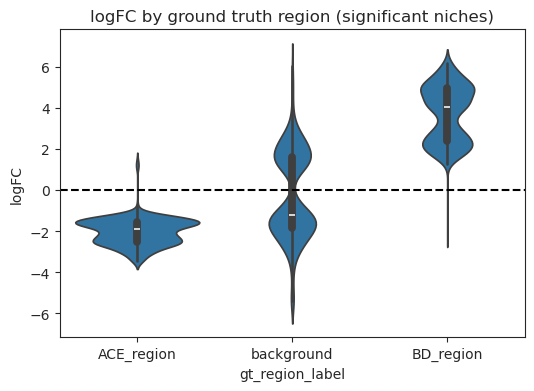

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sig = quiche_var[quiche_var["SpatialFDR"] < 0.05]

plt.figure(figsize=(6, 4))
sns.violinplot(
    data=sig,
    x="gt_region_label",
    y="logFC",
)
plt.axhline(0, color="black", linestyle="--")
plt.title("logFC by ground truth region (significant niches)")
plt.show()

### Annotate Niches

In [ ]:
quiche_op.annotate_niches(
    annotation_scheme="neighborhood",
    annotation_key="quiche_niche",
    nlargest=3,
    min_perc=0.1,
)

annotated = quiche_op.mdata["quiche"].var.copy()

INFO:quiche.tools.quiche:Annotating niches using scheme: neighborhood...
Labeling Niches: 100%|██████████| 99971/99971 [00:02<00:00, 40465.71it/s]


,quiche_niche,logFC,SpatialFDR
98744,B__D,6.159980,4.143447e-22
79163,B__D,6.160021,4.143447e-22
62927,B__D,6.159997,4.143447e-22
59931,B__D,6.160032,4.143447e-22
87271,B__D,6.159867,4.143447e-22
67555,B__D,6.159984,4.143447e-22
64057,B__D,6.143632,6.363849e-22
87042,B__D,6.143499,6.363849e-22
63654,B__D,6.057841,1.285082e-20
59005,B__D,6.057879,1.285082e-20


## Check Recovery vs Groundtruth
This is the key Phase 3 validation.

We want to see if:

- ACE-like niches appear enriched in condition 0
- BD-like niches appear enriched in condition 1

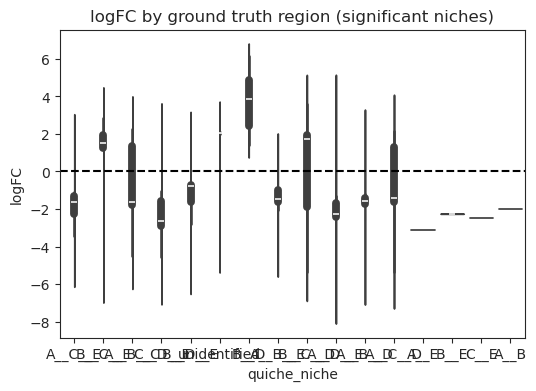

In [33]:
sig = annotated.loc[annotated["SpatialFDR"] < 0.05].copy()

plt.figure(figsize=(6, 4))
sns.violinplot(
    data=sig,
    x="quiche_niche",
    y="logFC",
)
plt.axhline(0, color="black", linestyle="--")
plt.title("logFC by ground truth region (significant niches)")
plt.show()

In [11]:
sig = annotated.loc[annotated["SpatialFDR"] < 0.05].copy()

display(sig[["quiche_niche", "logFC", "SpatialFDR"]])

,quiche_niche,logFC,SpatialFDR
17,A__C__E,-3.106251,6.902593e-07
22,A__C__E,-1.275790,4.518812e-02
23,A__C__E,-2.080244,4.213632e-02
117,B__C__E,-1.214165,1.949700e-02
156,A__C__E,-3.008975,5.642474e-05
...,...,...,...
99852,B__D,4.161137,5.337035e-08
99877,B__C__E,-2.491328,2.328110e-02
99882,A__C__E,1.197948,3.057247e-02
99900,B__D,3.609322,7.077055e-04


now inspect:

In [12]:
print("Top enriched niches (positive logFC):")
display(sig.sort_values("logFC", ascending=False).head(10)[["quiche_niche", "logFC"]])

print("\nTop depleted niches (negative logFC):")
display(sig.sort_values("logFC", ascending=True).head(10)[["quiche_niche", "logFC"]])

Top enriched niches (positive logFC):


,quiche_niche,logFC
59931,B__D,6.160032
79163,B__D,6.160021
62927,B__D,6.159997
67555,B__D,6.159984
98744,B__D,6.159980
87271,B__D,6.159867
64057,B__D,6.143632
87042,B__D,6.143499
59005,B__D,6.057879
58869,B__D,6.057879



Top depleted niches (negative logFC):


,quiche_niche,logFC
25206,A__C__E,-5.414662
5443,B__D__E,-5.361193
14488,C__D__E,-5.360550
7012,B__D__E,-5.360340
2884,C__D__E,-5.359702
3915,A__D__E,-5.359485
8525,C__D__E,-5.358796
22455,C__D__E,-5.358362
13977,A__C__E,-5.358008
12794,B__D__E,-5.357637


### Sanity check against planted region labels
We compare:

- predicted niches
- actual planted region (gt_region_label)

In [13]:
niche_obs = quiche_op.mdata["spatial_nhood"].obs.copy()

display(niche_obs.head())

,Patient_ID,condition,fov,label,cell_cluster,cell_type,gt_region_label,in_niche_voxel,nhood_ixs_random,nhood_ixs_refined,nhood_kth_distance,quiche_niche
0,P00,0,P00,P00_cell_0,B,B,background,False,1,1,0.056371,B__C__D
1,P00,0,P00,P00_cell_1,D,D,background,False,1,1,0.117851,B__E
2,P00,0,P00,P00_cell_2,B,B,background,False,1,1,0.060606,C__D__E
3,P00,0,P00,P00_cell_3,A,A,background,False,1,1,0.064788,A__C__E
4,P00,0,P00,P00_cell_4,C,C,background,False,1,1,0.091054,C__D__E


Check distribution

In [14]:
print("Ground truth region distribution:")
print(niche_obs["gt_region_label"].value_counts())

print("\nAnnotated niche distribution:")
print(niche_obs["quiche_niche"].value_counts().head(10))

Ground truth region distribution:
gt_region_label
background    96249
BD_region      1898
ACE_region     1824
Name: count, dtype: int64

Annotated niche distribution:
quiche_niche
C__D__E    13694
B__D__E    11242
A__C__E    11158
B__C__E     9923
A__D__E     9555
B__C__D     9273
A__B__E     7957
A__B__D     7764
A__C__D     7711
A__B__C     6903
Name: count, dtype: int64


The above does not give a lot of info as niches overlap and thereby covers the same cell multiple times. 

Below are a Ground Truth vs Annotated labels

### Simple recovery metric
Check whether predicted niches overlap with ground truth region:

In [15]:
# fraction of ACE_region cells assigned to top ACE-like niches
ace_cells = niche_obs[niche_obs["gt_region_label"] == "ACE_region"]

display(
    ace_cells["quiche_niche"].value_counts(normalize=True).head(10)
)

quiche_niche
A__C__E    0.736842
C__D__E    0.037281
A__E       0.034539
A__D__E    0.029605
B__C__E    0.029605
C__E       0.027961
A__B__C    0.026316
A__C       0.023026
A__C__D    0.020285
A__B__E    0.019737
Name: proportion, dtype: float64

Same for BD

In [16]:
bd_cells = niche_obs[niche_obs["gt_region_label"] == "BD_region"]

display(
    bd_cells["quiche_niche"].value_counts(normalize=True).head(10)
)

quiche_niche
B__D       0.626449
B__C__D    0.126976
A__B__D    0.114331
B__D__E    0.081665
C__D__E    0.009484
B          0.006849
A__B__E    0.006322
D          0.004742
A__D__E    0.004742
A__B__C    0.004215
Name: proportion, dtype: float64

## Success criteria for phase 3

1. Significant niches exist
    - SpatialFDR < 0.05 for some niches
2. Correct directionality
    - ACE-like niches → positive logFC for condition 0
    - BD-like niches → negative logFC (or vice versa depending on contrast)
3. Interpretability
    - annotated niches contain expected cell types:
        - "A__C__E" (or similar)
        - "B__D" (or similar)
4. Alignment with ground truth
    - ACE_region cells map preferentially to ACE-like niches
    - BD_region cells map preferentially to BD-like niches

# Visualize

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

sample_id = niche_obs["Patient_ID"].cat.categories[1]

# expression obs has coordinates
expr_obs = quiche_op.mdata["expression"].obs.copy()
coords = quiche_op.mdata["expression"].obsm["spatial3d"]

plot_df = expr_obs.copy()
plot_df["x"] = coords[:, 0]
plot_df["y"] = coords[:, 1]
plot_df["z"] = coords[:, 2]

# add QUICHE annotation from spatial_nhood obs
nhood_obs = quiche_op.mdata["spatial_nhood"].obs[["quiche_niche"]].copy()
plot_df = plot_df.join(nhood_obs["quiche_niche"], how="left")

# choose one patient
df = plot_df[plot_df["Patient_ID"] == sample_id].copy()

# choose a z slice around the middle
z_mid = df["z"].median()
slice_width = 20

df_slice = df[
    (df["z"] >= z_mid - slice_width / 2) &
    (df["z"] <= z_mid + slice_width / 2)
].copy()

print("Cells in slice:", df_slice.shape[0])

Cells in slice: 382


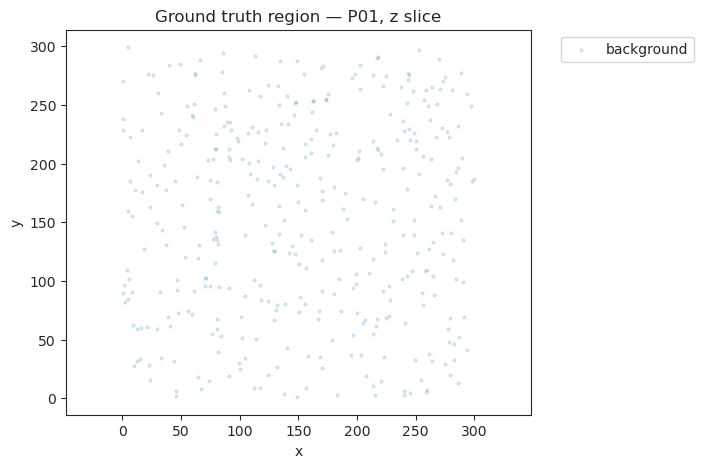

In [41]:
plt.figure(figsize=(6, 5))

for label, sub in df_slice.groupby("gt_region_label"):
    alpha = 0.15 if label == "background" else 0.95
    size = 4 if label == "background" else 14
    plt.scatter(sub["x"], sub["y"], s=size, alpha=alpha, label=label)

plt.title(f"Ground truth region — {sample_id}, z slice")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

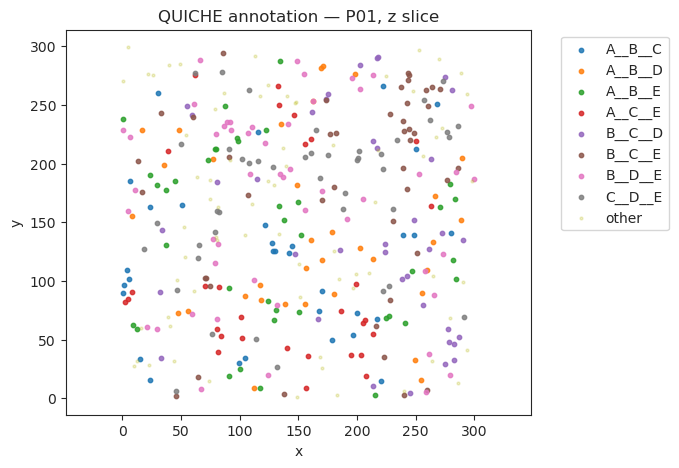

In [43]:
# show only top annotations to avoid unreadable legends
top_n = 8
top_labels = df_slice["quiche_niche"].value_counts().head(top_n).index

df_slice["quiche_niche_plot"] = df_slice["quiche_niche"].where(
    df_slice["quiche_niche"].isin(top_labels),
    "other"
)

plt.figure(figsize=(6, 5))

for label, sub in df_slice.groupby("quiche_niche_plot"):
    alpha = 0.25 if label == "other" else 0.85
    size = 4 if label == "other" else 10
    plt.scatter(sub["x"], sub["y"], s=size, alpha=alpha, label=label)

plt.title(f"QUICHE annotation — {sample_id}, z slice")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## Viz 3D

In [46]:
# Build plotting dataframe
expr_obs = quiche_op.mdata["expression"].obs.copy()
coords = quiche_op.mdata["expression"].obsm["spatial3d"]

plot_df = expr_obs.copy()
plot_df["x"] = coords[:, 0]
plot_df["y"] = coords[:, 1]
plot_df["z"] = coords[:, 2]

nhood_obs = quiche_op.mdata["spatial_nhood"].obs[["quiche_niche"]].copy()
plot_df = plot_df.join(nhood_obs["quiche_niche"], how="left")

In [47]:
def pick_patient_for_condition(plot_df, condition):
    candidates = (
        plot_df[
            (plot_df["condition"].astype(str) == str(condition)) &
            (plot_df["gt_region_label"] != "background")
        ]["Patient_ID"]
        .unique()
    )
    if len(candidates) == 0:
        raise ValueError(f"No niche-positive patient found for condition {condition}")
    return candidates[0]


def plot_3d_gt_and_annotation_for_patient(
    plot_df,
    patient_id,
    top_n=6,
    annotate_from_region=True,
):
    df = plot_df[plot_df["Patient_ID"] == patient_id].copy()

    condition = str(df["condition"].iloc[0])
    gt_labels = sorted(df["gt_region_label"].unique())

    non_background = df["gt_region_label"] != "background"

    # choose annotation labels to highlight
    if annotate_from_region and non_background.any():
        top_labels = (
            df.loc[non_background, "quiche_niche"]
            .value_counts()
            .head(top_n)
            .index
        )
    else:
        top_labels = (
            df["quiche_niche"]
            .value_counts()
            .head(top_n)
            .index
        )

    df["quiche_niche_plot"] = df["quiche_niche"].where(
        df["quiche_niche"].isin(top_labels),
        "other"
    )

    fig = plt.figure(figsize=(14, 6))

    # -------------------------
    # Left: ground truth
    # -------------------------
    ax1 = fig.add_subplot(121, projection="3d")

    bg = df["gt_region_label"] == "background"

    ax1.scatter(
        df.loc[bg, "x"],
        df.loc[bg, "y"],
        df.loc[bg, "z"],
        s=3,
        alpha=0.03,
        label="background",
    )

    for gt_label, sub in df.loc[~bg].groupby("gt_region_label"):
        ax1.scatter(
            sub["x"],
            sub["y"],
            sub["z"],
            s=14,
            alpha=0.9,
            label=gt_label,
        )

    ax1.set_title(f"GT region\n{patient_id}, condition {condition}")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("z")
    ax1.legend(loc="upper left")

    # -------------------------
    # Right: QUICHE annotation
    # -------------------------
    ax2 = fig.add_subplot(122, projection="3d")

    for label, sub in df.groupby("quiche_niche_plot"):
        is_other = label == "other"
        ax2.scatter(
            sub["x"],
            sub["y"],
            sub["z"],
            s=3 if is_other else 12,
            alpha=0.03 if is_other else 0.85,
            label=label,
        )

    ax2.set_title(f"QUICHE annotation\n{patient_id}, condition {condition}")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_zlabel("z")
    ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    # same viewing angle
    ax1.view_init(elev=20, azim=35)
    ax2.view_init(elev=20, azim=35)

    # same axis limits
    for ax in [ax1, ax2]:
        ax.set_xlim(df["x"].min(), df["x"].max())
        ax.set_ylim(df["y"].min(), df["y"].max())
        ax.set_zlim(df["z"].min(), df["z"].max())

    plt.tight_layout()
    plt.show()

In [48]:
patient_cond0 = pick_patient_for_condition(plot_df, condition=0)
patient_cond1 = pick_patient_for_condition(plot_df, condition=1)

print("Condition 0 patient:", patient_cond0)
print("Condition 1 patient:", patient_cond1)

Condition 0 patient: P00
Condition 1 patient: P10


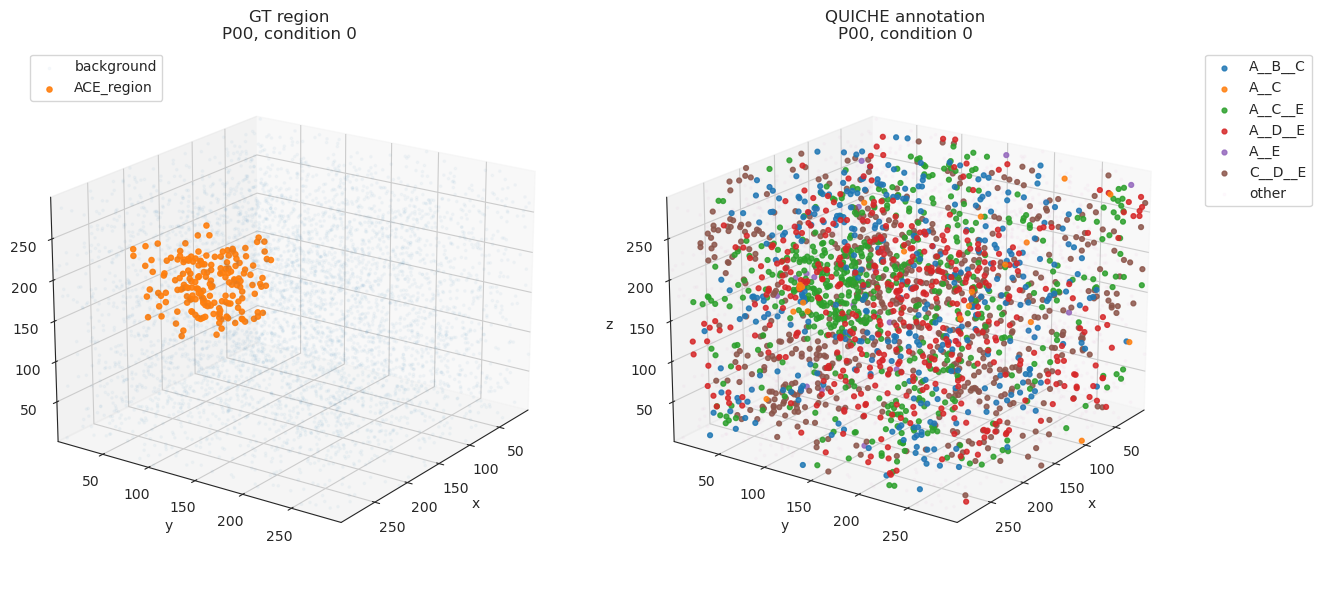

In [49]:
plot_3d_gt_and_annotation_for_patient(
    plot_df,
    patient_id=patient_cond0,
    top_n=6,
    annotate_from_region=True,
)

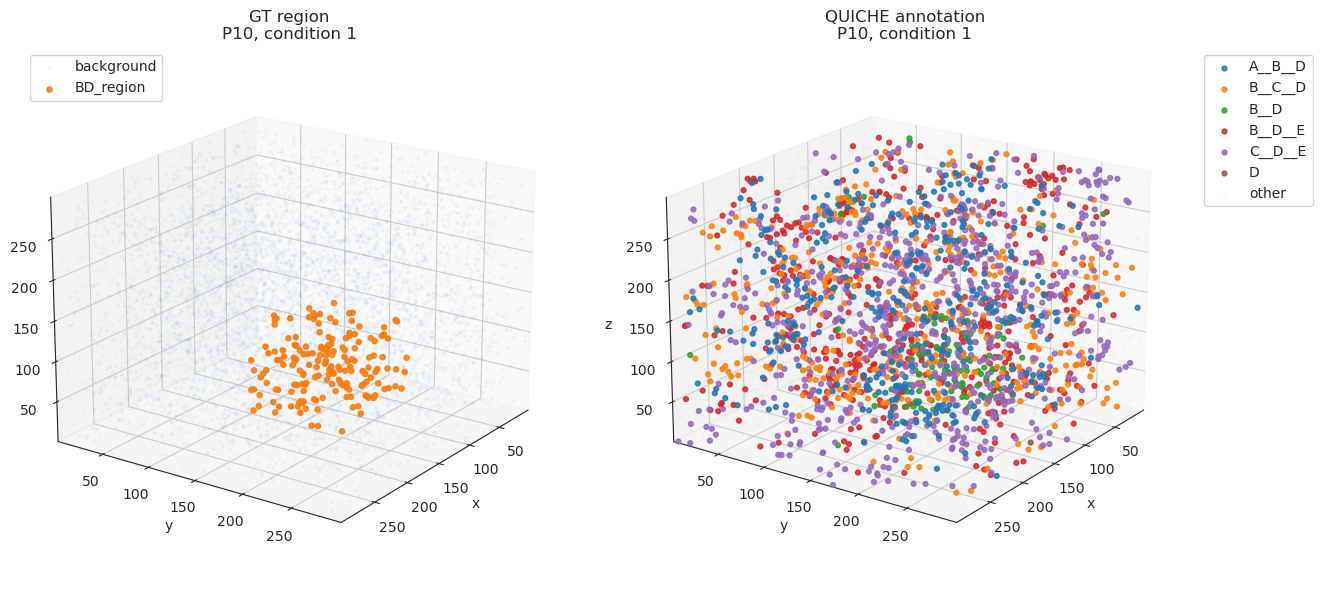

In [50]:
plot_3d_gt_and_annotation_for_patient(
    plot_df,
    patient_id=patient_cond1,
    top_n=6,
    annotate_from_region=True,
)